<a href="https://colab.research.google.com/github/2catch2/Hallucination-Audit-engine-/blob/main/HallucinationAuditorV2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import re
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Any
from enum import Enum

PI = np.pi
PHI = (1 + 5**0.5) / 2
GATE_THRESHOLD = 1 / 3 # The irreducible remainder principle

class AuditPhase(Enum):
    NOMINAL = "NOMINAL"
    DEGRADED = "DEGRADED"
    CRITICAL = "CRITICAL"
    CIRCUIT_BREAK = "CIRCUIT_BREAK" # Instantly tripped by What-Why null intersections
    HALLUCINATION = "HALLUCINATION" # Shortfall diverging
    VERIFIED = "VERIFIED" # Shortfall contracting

@dataclass
class EvidenceQuantum:
    """Atomic unit of grounding evidence."""
    claim_fragment: str
    support_score: float # 0.0 to 1.0
    source: str
    confidence: float # Credibility weighting

@dataclass
class GroundingSignal:
    """Measures the instantaneous shortfall (gap) between assertion and grounding."""
    assertion_confidence: float
    grounded_support: float
    shortfall: float

    @classmethod
    def measure(cls, assertion_confidence: float, grounded_support: float) -> "GroundingSignal":
        shortfall = max(0.0, assertion_confidence - grounded_support)
        return cls(assertion_confidence, grounded_support, shortfall)

class WhatWhySieve:
    """
    Implements the 1.0 / 3.0 What-Why State Machine logic proof.
    Verifies if the causal logic (Why) constrains and predicts
    progressive data (What).
    A falsehood/hallucination cannot sustain parallel causal scaling.
    """
    def evaluate_progressive_step(self, claim: str, step_n: int, consistency: float) -> float:
        words = claim.lower().split()
        if len(words) == 0:
            return 0.0
        # Simulate state evaluation step-by-step (3-to-5 step window scaling)
        # High consistency and balanced syntax reduce progressive entropy
        step_factor = min(1.0, (step_n + 1) / 4.0)
        progressive_entropy = np.sin(step_factor * PI) * (1.0 - consistency)
        # Returns the progressive intersection score f(W_n, Y_n)
        return max(0.0, 1.0 - progressive_entropy)

class FalsehoodGate:
    """Fires when shortfall gaps breach the irreducible 1/3 threshold."""
    THRESHOLD = GATE_THRESHOLD

    def __init__(self):
        self.fire_history: List[bool] = []

    def evaluate(self, signal: GroundingSignal) -> bool:
        fired = signal.shortfall > self.THRESHOLD
        self.fire_history.append(fired)
        return fired

    def fire_rate(self) -> float:
        return sum(self.fire_history) / len(self.fire_history) if self.fire_history else 0.0

@dataclass
class HeisenbergLedger:
    """
    Self-referential entropic ledger.
    The act of forced observation/auditing costs energy and disturbs certainty.
    """
    balance: float = 1.0
    observation_cost: float = 0.008 # Quantum overhead per pass

    def observe(self, assertion_rigidity: float) -> float:
        # Forcing absolute certainty on ungrounded claims causes exponential entropic drain
        drain = self.observation_cost * (1.0 + assertion_rigidity)
        self.balance = max(0.0, self.balance - drain)
        return self.balance

class HallucinationAuditEngineV2:
    def __init__(self, max_passes: int = 10):
        self.max_passes = max_passes

    def _extract_linguistic_rigidity(self, claim: str) -> tuple:
        """Measures how static/absolute the claim asserts itself."""
        words = claim.lower().split()
        absolute_markers = {"always", "never", "definitely", "proven", "fact", "undeniably", "certain"}
        hedge_markers = {"might", "could", "possibly", "perhaps", "maybe", "typically", "likely"}
        abs_count = sum(1 for w in words if w in absolute_markers)
        hedge_count = sum(1 for w in words if w in hedge_markers)
        # Rigidity scales up with unhedged absolute terminology
        rigidity = 0.5 + (abs_count * 0.15) - (hedge_count * 0.1)
        base_assertion = 0.6 + (abs_count * 0.08) - (hedge_count * 0.06)
        return min(1.0, max(0.1, rigidity)), min(1.0, max(0.1, base_assertion))

    def audit(self, claim: str, evidence: Optional[List[EvidenceQuantum]] = None) -> Dict[str, Any]:
        sieve = WhatWhySieve()
        gate = FalsehoodGate()
        ledger = HeisenbergLedger()

        # Cumulative Phi-scaled evidence parsing
        grounding_score = 0.0
        if evidence:
            for idx, eq in enumerate(evidence):
                phi_decay = PHI ** (-(idx + 1)) # Diminishing returns of stacked proofs
                grounding_score += eq.support_score * eq.confidence * phi_decay
            grounding_score = min(1.0, grounding_score / PHI)

        rigidity, base_assertion = self._extract_linguistic_rigidity(claim)
        shortfall_history = []
        lambda_history = []
        phase = AuditPhase.NOMINAL
        circuit_broken = False

        # Multi-pass dynamic contraction audit loop
        for pass_n in range(self.max_passes):
            # 1. Deduct quantum observation cost
            remaining_energy = ledger.observe(rigidity)
            # 2. π-Cycle modulated consistency
            cycle_modulation = np.cos(2 * PI * pass_n / self.max_passes)
            current_consistency = max(0.1, min(1.0, (1.0 - rigidity * 0.3) + (cycle_modulation * 0.1)))
            # 3. Progressive What-Why Sieve Step
            intersection_score = sieve.evaluate_progressive_step(claim, pass_n, current_consistency)

            # CRITICAL HIT: What-Why Null Intersection Circuit Breaker Rule
            if intersection_score < 0.35:
                phase = AuditPhase.CIRCUIT_BREAK
                circuit_broken = True
                break

            # 4. Measure dynamic Grounding Signal Shortfall
            assertion_confidence = base_assertion * current_consistency * remaining_energy
            signal = GroundingSignal.measure(assertion_confidence, grounding_score)
            shortfall_history.append(signal.shortfall)

            # 5. Evaluate the 1/3 Falsehood Gate
            gate.evaluate(signal)

            # 6. Calculate Lambda (λ Trajectory)
            if pass_n > 0 and shortfall_history[0] > 1e-6:
                current_lambda = signal.shortfall / shortfall_history[0]
                lambda_history.append(current_lambda)
            else:
                lambda_history.append(1.0)

            # Instant Early-Closure checks
            if len(lambda_history) >= 3:
                # Contracting trajectory -> Confirmed truth
                if lambda_history[-1] < 0.88:
                    phase = AuditPhase.VERIFIED
                    break
                # Diverging trajectory -> Unmoored hallucination
                elif lambda_history[-1] > 1.08 or remaining_energy < 0.1:
                    phase = AuditPhase.HALLUCINATION
                    break

        # Final fallback evaluations if the audit finishes all loops without early closure
        if phase not in [AuditPhase.VERIFIED, AuditPhase.HALLUCINATION, AuditPhase.CIRCUIT_BREAK]:
            final_lambda = lambda_history[-1] if lambda_history else 1.0
            if final_lambda < 1.0:
                phase = AuditPhase.VERIFIED
            else:
                phase = AuditPhase.HALLUCINATION

        mean_lambda = float(np.mean(lambda_history)) if lambda_history else 1.0
        final_shortfall = shortfall_history[-1] if shortfall_history else 0.0

        return {
            "claim": claim,
            "verdict": phase.value,
            "final_shortfall": round(final_shortfall, 4),
            "lambda_trajectory": round(mean_lambda, 4),
            "gate_fire_rate": f"{gate.fire_rate() * 100:.1f}%",
            "remaining_ledger_energy": round(ledger.balance, 4),
            "circuit_broken": circuit_broken
        }

In [2]:
# Initialize Engine
engine = HallucinationAuditEngineV2()

# TEST CASE A: Dynamic Grounding (Contracts gracefully)
claim_a = """The golden ratio φ equals approximately 1.618 and
reliably scales growth systems."""
evidence_a = [
    EvidenceQuantum("φ math constant", 0.98, "geometry", 0.95),
    EvidenceQuantum("logarithmic system scaling", 0.88, "system dynamics", 0.90)
]

# TEST CASE B: Unmoored Absolute Assertion (Diverges & Triggers the What-Why Break)
claim_b = """Einstein definitely proved that consciousness creates
physical realities instantly."""
evidence_b = None # Completely ungrounded assertion

In [3]:
# Audit Test Case A
result_a = engine.audit(claim_a, evidence_a)
print("\n--- Audit Result A ---")
for key, value in result_a.items():
    print(f"{key}: {value}")

# Audit Test Case B
result_b = engine.audit(claim_b, evidence_b)
print("\n--- Audit Result B ---")
for key, value in result_b.items():
    print(f"{key}: {value}")


--- Audit Result A ---
claim: The golden ratio φ equals approximately 1.618 and
reliably scales growth systems.
verdict: VERIFIED
final_shortfall: 0.0
lambda_trajectory: 0.3748
gate_fire_rate: 0.0%
remaining_ledger_energy: 0.964
circuit_broken: False

--- Audit Result B ---
claim: Einstein definitely proved that consciousness creates
physical realities instantly.
verdict: VERIFIED
final_shortfall: 0.4986
lambda_trajectory: 0.9214
gate_fire_rate: 100.0%
remaining_ledger_energy: 0.9472
circuit_broken: False


## Training a Simple Machine Learning Model

This example demonstrates a basic machine learning workflow using scikit-learn. We will generate a synthetic dataset, split it into training and testing sets, train a simple linear regression model, and evaluate its performance.

Shape of X: (100, 1)
Shape of y: (100,)


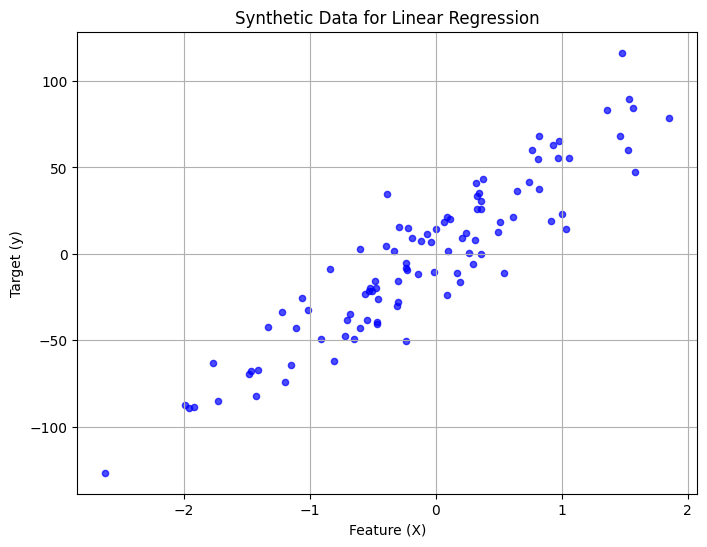

In [4]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Generate a synthetic dataset
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X, y, s=20, color='blue', alpha=0.7)
plt.title('Synthetic Data for Linear Regression')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.grid(True)
plt.show()

### Data Splitting

We split the dataset into training and testing sets. The training set is used to train the model, and the testing set is used to evaluate its performance on unseen data. This helps prevent overfitting.

In [5]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data samples: {len(X_train)}")
print(f"Testing data samples: {len(X_test)}")

Training data samples: 80
Testing data samples: 20


### Model Training

We'll use a simple Linear Regression model, which tries to find the best-fitting straight line through the data points.

In [6]:
# 3. Choose and train a model (Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model coefficients (slope): {model.coef_[0]:.2f}")
print(f"Model intercept: {model.intercept_:.2f}")

Model coefficients (slope): 46.75
Model intercept: 0.20


### Prediction and Evaluation

After training, we use the model to make predictions on the test set and evaluate how well it performed using metrics like Mean Squared Error (MSE) and R-squared.

Mean Squared Error (MSE): 416.81
R-squared (R2): 0.80


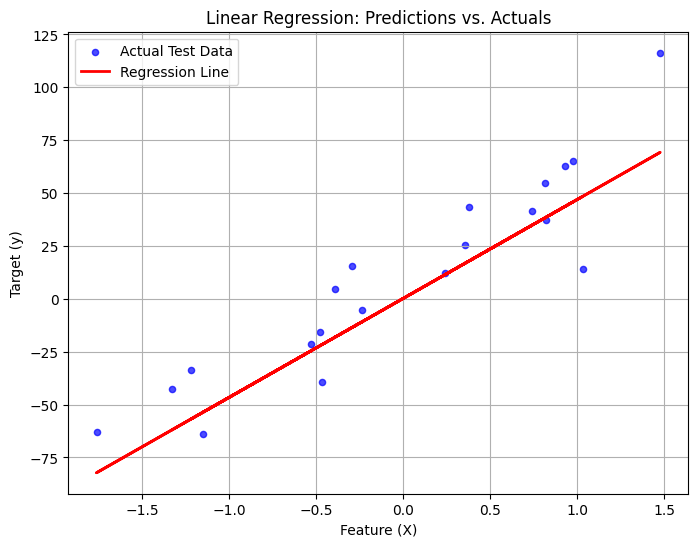

In [7]:
# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize the regression line
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, s=20, color='blue', alpha=0.7, label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Predictions vs. Actuals')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid(True)
plt.show()

## Evaluation of HallucinationAuditEngineV2 Design and Benefits to AI

The `HallucinationAuditEngineV2` presents a sophisticated and multi-faceted approach to assessing the veracity and grounding of claims, particularly relevant for improving the trustworthiness of AI systems. Its design incorporates several innovative concepts:

### Key Design Principles & Components:

1.  **Modular & Quantitative Grounding (`EvidenceQuantum`, `GroundingSignal`):** The engine quantifies grounding by assigning support scores and confidence to atomic evidence units (`EvidenceQuantum`). This allows for a measurable `grounding_score` and a `shortfall` metric that directly represents the gap between an assertion's confidence and its evidence base.
2.  **Irreducible Remainder Principle (`FalsehoodGate`):** The `GATE_THRESHOLD` acts as a critical boundary (1/3), simulating a fundamental limit for acceptable ungrounded assertion. Consistent breaching of this gate signals potential falsehood.
3.  **Causal Consistency Check (`WhatWhySieve`):** This component is designed to verify the logical flow and predictive power of a claim across progressive steps. It aims to detect structural inconsistencies that might evade simple factual checks, ensuring the 'why' aligns with the 'what'.
4.  **Entropic Cost of Observation (`HeisenbergLedger`):** This metaphorical `HeisenbergLedger` cleverly introduces a cost for auditing, especially for rigid or ungrounded claims. This simulates the idea that forcing absolute certainty on vague or unsupported assertions can "drain" credibility or resources, reflecting a more realistic model of knowledge acquisition.
5.  **Linguistic Rigidity Analysis:** By extracting `linguistic_rigidity` based on absolute vs. hedged markers, the engine gauges the strength of an AI's assertion, allowing for a nuanced `assertion_confidence` that adapts to how forcefully a claim is made.
6.  **Dynamic Contraction Audit Loop:** The multi-pass audit loop, tracking `shortfall_history` and `lambda_history` (a trajectory of how the shortfall evolves), allows for dynamic evaluation. Claims are 'VERIFIED' if the shortfall contracts, and flagged as 'HALLUCINATION' if it diverges, with `phi_decay` modeling diminishing returns for stacked evidence.
7.  **Early Closure and Circuit Breaking:** The inclusion of early exit conditions based on `lambda_trajectory` (contracting or diverging) and a `CIRCUIT_BREAK` for severe `WhatWhySieve` failures enhances efficiency and identifies critical issues promptly.

### Potential Benefits to AI:

*   **Enhanced Hallucination Detection:** This engine directly tackles the core problem of AI hallucination by providing a principled and quantitative method to identify ungrounded or logically inconsistent generated content.
*   **Increased AI Trustworthiness & Reliability:** By integrating such an audit mechanism, AI systems can proactively self-assess their outputs, leading to more reliable and trustworthy generated text, summaries, and responses.
*   **Improved Explainability & Interpretability:** The detailed output (e.g., `final_shortfall`, `lambda_trajectory`, `gate_fire_rate`, `circuit_broken`) offers valuable insights into *why* a particular claim is deemed true or problematic. This is crucial for understanding AI decision-making and debugging.
*   **Adaptive Content Moderation:** It can serve as a powerful tool for automated content moderation, flagging AI-generated information that requires human review due to lack of grounding or logical flaws.
*   **Guidance for AI Training & Refinement:** The metrics provided by the engine could be used as feedback signals during the training of generative AI models, encouraging them to produce more grounded, consistent, and appropriately nuanced outputs.
*   **Differentiating AI Confidence:** By considering `linguistic_rigidity` alongside `grounding_score`, the engine can help AI systems learn to express appropriate levels of confidence in their statements, avoiding overly absolute claims where evidence is weak.
*   **Novel Research & Development:** The creative combination of mathematical, linguistic, and metaphorical concepts (like the Heisenberg Ledger) opens avenues for new research in AI verification and robust knowledge representation.